# 2. Feature Engineering

**Course:** TC5035.10 - Capstone project
**Tecnológico de Monterrey**

**Professor:** Raúl Valente Ramírez Velarde

---
**Team:** 57
> César Miguel Barrientos Robles - A01796615
>
> Alan Julian Rodríguez García - A01796833

## Context

This notebook picks up where the EDA left off. The raw data — 2,057 samples of 21 MediaPipe hand
landmarks across 26 LSM letters — is clean and complete, but not yet in a form that maximizes
classifier performance.

In this phase (Feature Engineering), we will:

1. **Generate new features** — inter-landmark distances, joint angles, and finger curl ratios that
   encode the hand's geometric pose more explicitly than raw coordinates.
2. **Encode categorical variables** — label-encode the target (`letter`) and binary-encode `handedness`.
3. **Scale and normalize** — apply wrist-relative normalization (position + scale invariance) and
   standardization (zero mean, unit variance).
4. **Transform skewed features** — use Yeo-Johnson to reduce the heavy skew detected in depth (z)
   coordinates during the EDA.
5. **Select features** — variance threshold, correlation filtering, and ANOVA F-test to remove
   uninformative or redundant columns.
6. **Extract features** — PCA to compress the remaining variance into a lower-dimensional space.

Every decision is justified based on the EDA findings.

## Data Loading

In [1]:
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, f_classif
from sklearn.decomposition import PCA

from manos_hablando.config import PROCESSED_DATA_DIR

2026-05-20 22:05:38.782 | INFO     | manos_hablando.config:<module>:11 - PROJ_ROOT path is: /Users/cbarrien/Documents/Projects/Personal/LSM/manos-hablando


In [2]:
LANDMARK_NAMES = [
    "WRIST",
    "THUMB_CMC", "THUMB_MCP", "THUMB_IP", "THUMB_TIP",
    "INDEX_MCP", "INDEX_PIP", "INDEX_DIP", "INDEX_TIP",
    "MIDDLE_MCP", "MIDDLE_PIP", "MIDDLE_DIP", "MIDDLE_TIP",
    "RING_MCP", "RING_PIP", "RING_DIP", "RING_TIP",
    "PINKY_MCP", "PINKY_PIP", "PINKY_DIP", "PINKY_TIP",
]

# Build column names
columns = []
for name in LANDMARK_NAMES:
    for coord in ["x", "y", "z"]:
        columns.append(f"{name}_{coord}")

# Load and flatten
with open(PROCESSED_DATA_DIR / "keypoints.json") as f:
    data = json.load(f)

rows = []
for entry in data:
    row = {
        "letter": entry["letter"],
        "file": entry["file"],
        "handedness": entry["handedness"],
        "handedness_confidence": entry["handedness_confidence"],
    }

    # image keypoints
    flat = [coord for point in entry["keypoints"] for coord in point]
    row.update(dict(zip(columns, flat)))

    # world keypoints
    world_columns = [f"{name}_w{coord}" for name in LANDMARK_NAMES for coord in ["x", "y", "z"]]
    flat_world = [coord for point in entry["world_keypoints"] for coord in point]
    row.update(dict(zip(world_columns, flat_world)))

    rows.append(row)

df = pd.DataFrame(rows)

print(f"Loaded {df.shape[0]} samples, {df.shape[1]} columns")
display(df.head(3))

Loaded 2057 samples, 130 columns


,letter,file,handedness,handedness_confidence,WRIST_x,WRIST_y,WRIST_z,THUMB_CMC_x,THUMB_CMC_y,THUMB_CMC_z,...,PINKY_MCP_wz,PINKY_PIP_wx,PINKY_PIP_wy,PINKY_PIP_wz,PINKY_DIP_wx,PINKY_DIP_wy,PINKY_DIP_wz,PINKY_TIP_wx,PINKY_TIP_wy,PINKY_TIP_wz
0,A,A_63.jpg,Right,0.618247,0.215690,0.391573,1.093951e-06,0.353929,0.506949,-0.061486,...,0.006652,-0.013173,0.006764,-0.000570,-0.009514,0.017215,-0.004708,-0.002251,0.029172,-0.014473
1,A,A_6.jpg,Right,0.997630,0.799894,0.614623,-5.651171e-07,0.724600,0.438284,-0.026929,...,-0.010846,-0.011160,0.036658,-0.028339,-0.001282,0.027936,-0.048126,0.015557,0.026138,-0.038945
2,A,A_62.jpg,Right,0.893355,0.776529,0.625856,1.103114e-06,0.635659,0.491809,-0.066883,...,0.004921,0.031558,-0.005056,-0.000782,0.033954,-0.020744,-0.005247,0.032533,-0.031525,-0.007702


## 1. Feature Generation

The EDA showed that raw landmark coordinates are highly multicollinear (r > 0.98 between adjacent
joints) and position-dependent (image-space x/y shift with hand placement in frame). We generate
new features that encode **geometric relationships** rather than absolute positions:

- **Fingertip-to-wrist distances** — how extended each finger is (5 features).
- **Inter-fingertip distances** — relative spread between fingers (10 pairwise features).
- **Joint angles** — the bend at each PIP and MCP joint per finger, computed via the dot-product
  formula on the bone vectors (10 features).
- **Finger curl ratios** — tip-to-wrist distance divided by total bone chain length; 0 = fully
  curled, 1 = fully extended (5 features).

All distances and angles are computed from **world coordinates** (position/scale-invariant), as
the EDA concluded these are more geometrically consistent than image coordinates.

In [3]:
# Helper: get world-coordinate 3D vector for a landmark
def get_world_point(df, name):
    return df[[f"{name}_wx", f"{name}_wy", f"{name}_wz"]].values

# Define finger chains: MCP → PIP → DIP → TIP
FINGERS = {
    "THUMB":  ["WRIST", "THUMB_CMC", "THUMB_MCP", "THUMB_IP",  "THUMB_TIP"],
    "INDEX":  ["WRIST", "INDEX_MCP", "INDEX_PIP", "INDEX_DIP", "INDEX_TIP"],
    "MIDDLE": ["WRIST", "MIDDLE_MCP","MIDDLE_PIP","MIDDLE_DIP","MIDDLE_TIP"],
    "RING":   ["WRIST", "RING_MCP",  "RING_PIP",  "RING_DIP",  "RING_TIP"],
    "PINKY":  ["WRIST", "PINKY_MCP", "PINKY_PIP", "PINKY_DIP", "PINKY_TIP"],
}

FINGERTIPS = ["THUMB_TIP", "INDEX_TIP", "MIDDLE_TIP", "RING_TIP", "PINKY_TIP"]

# --- 1a. Fingertip-to-wrist distances ---
wrist = get_world_point(df, "WRIST")
for tip_name in FINGERTIPS:
    tip = get_world_point(df, tip_name)
    finger = tip_name.split("_")[0]
    df[f"dist_wrist_{finger.lower()}"] = np.linalg.norm(tip - wrist, axis=1)

# --- 1b. Inter-fingertip distances (all 10 pairs) ---
from itertools import combinations
for (t1, t2) in combinations(FINGERTIPS, 2):
    p1, p2 = get_world_point(df, t1), get_world_point(df, t2)
    n1, n2 = t1.split("_")[0].lower(), t2.split("_")[0].lower()
    df[f"dist_{n1}_{n2}"] = np.linalg.norm(p1 - p2, axis=1)

# --- 1c. Joint angles (MCP and PIP for each finger) ---
def angle_between(v1, v2):
    """Angle in degrees between vectors v1 and v2 (row-wise)."""
    cos = np.sum(v1 * v2, axis=1) / (np.linalg.norm(v1, axis=1) * np.linalg.norm(v2, axis=1) + 1e-8)
    cos = np.clip(cos, -1, 1)
    return np.degrees(np.arccos(cos))

for finger, chain in FINGERS.items():
    # MCP angle: angle at chain[2] between chain[1]→chain[2] and chain[2]→chain[3]
    a, b, c = get_world_point(df, chain[1]), get_world_point(df, chain[2]), get_world_point(df, chain[3])
    df[f"angle_{finger.lower()}_mcp"] = angle_between(a - b, c - b)

    # PIP angle: angle at chain[3] between chain[2]→chain[3] and chain[3]→chain[4]
    b2, c2, d = get_world_point(df, chain[2]), get_world_point(df, chain[3]), get_world_point(df, chain[4])
    df[f"angle_{finger.lower()}_pip"] = angle_between(b2 - c2, d - c2)

# --- 1d. Finger curl ratios ---
for finger, chain in FINGERS.items():
    # Straight-line distance: wrist → tip
    tip_dist = np.linalg.norm(get_world_point(df, chain[-1]) - get_world_point(df, chain[0]), axis=1)
    # Chain length: sum of bone segments
    chain_len = np.zeros(len(df))
    for i in range(len(chain) - 1):
        seg = np.linalg.norm(get_world_point(df, chain[i+1]) - get_world_point(df, chain[i]), axis=1)
        chain_len += seg
    df[f"curl_{finger.lower()}"] = tip_dist / (chain_len + 1e-8)

# Summary
new_feat_cols = [c for c in df.columns if c.startswith(("dist_", "angle_", "curl_"))]
print(f"Generated {len(new_feat_cols)} new features:")
for prefix in ["dist_wrist", "dist_thumb", "dist_index", "dist_middle", "dist_ring",
               "angle_", "curl_"]:
    cols = [c for c in new_feat_cols if c.startswith(prefix)]
    if cols:
        print(f"  {prefix}*: {len(cols)} — {cols}")


Generated 30 new features:
  dist_wrist*: 5 — ['dist_wrist_thumb', 'dist_wrist_index', 'dist_wrist_middle', 'dist_wrist_ring', 'dist_wrist_pinky']
  dist_thumb*: 4 — ['dist_thumb_index', 'dist_thumb_middle', 'dist_thumb_ring', 'dist_thumb_pinky']
  dist_index*: 3 — ['dist_index_middle', 'dist_index_ring', 'dist_index_pinky']
  dist_middle*: 2 — ['dist_middle_ring', 'dist_middle_pinky']
  dist_ring*: 1 — ['dist_ring_pinky']
  angle_*: 10 — ['angle_thumb_mcp', 'angle_thumb_pip', 'angle_index_mcp', 'angle_index_pip', 'angle_middle_mcp', 'angle_middle_pip', 'angle_ring_mcp', 'angle_ring_pip', 'angle_pinky_mcp', 'angle_pinky_pip']
  curl_*: 5 — ['curl_thumb', 'curl_index', 'curl_middle', 'curl_ring', 'curl_pinky']


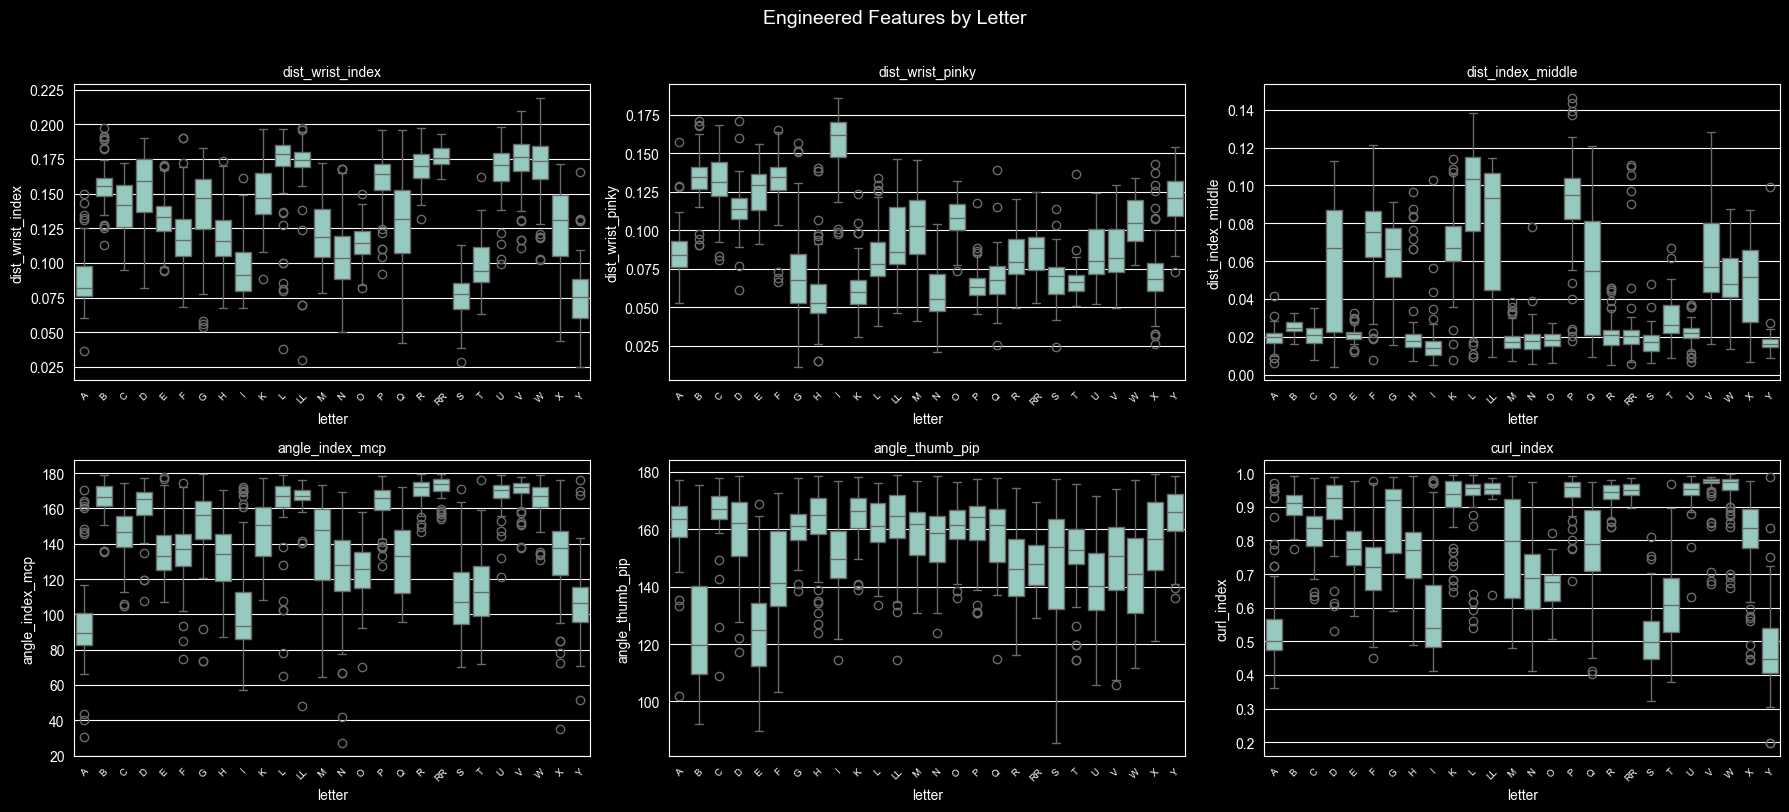

In [4]:
# Visualize a few engineered features by letter
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

plot_features = [
    "dist_wrist_index", "dist_wrist_pinky", "dist_index_middle",
    "angle_index_mcp", "angle_thumb_pip", "curl_index",
]

for ax, feat in zip(axes.flatten(), plot_features):
    sns.boxplot(x="letter", y=feat, data=df, ax=ax)
    ax.set_title(feat, fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=7)

plt.suptitle("Engineered Features by Letter", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Encoding

As established in the EDA, all categorical variables are **nominal** — no ordinal relationship exists.

- **`letter`** (target, 26 classes) → `LabelEncoder` to produce integer labels 0-25 for the
  classifier. One-hot encoding is unnecessary here because the target is used as a class index,
  not as an input feature.
- **`handedness`** (2 classes) → binary encoding (Right=1, Left=0). Since there are only two
  categories, one-hot would add a redundant column.
- **`file`** — dropped. It is a unique identifier, not a predictive feature.
- **`handedness_confidence`** — retained as-is (already numeric).

In [5]:
# Encode target variable
le = LabelEncoder()
df["label"] = le.fit_transform(df["letter"])

# Binary-encode handedness
df["hand_right"] = (df["handedness"] == "Right").astype(int)

# Drop non-predictive columns
df_model = df.drop(columns=["letter", "file", "handedness"])

print(f"Target classes ({len(le.classes_)}): {list(le.classes_)}")
print(f"\nHandedness encoding:")
print(df[["handedness", "hand_right"]].drop_duplicates().to_string(index=False))
print(f"\nModel DataFrame shape: {df_model.shape}")
display(df_model.head(3))

Target classes (26): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'LL', 'M', 'N', 'O', 'P', 'Q', 'R', 'RR', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']

Handedness encoding:
handedness  hand_right
     Right           1
      Left           0

Model DataFrame shape: (2057, 159)


,handedness_confidence,WRIST_x,WRIST_y,WRIST_z,THUMB_CMC_x,THUMB_CMC_y,THUMB_CMC_z,THUMB_MCP_x,THUMB_MCP_y,THUMB_MCP_z,...,angle_ring_pip,angle_pinky_mcp,angle_pinky_pip,curl_thumb,curl_index,curl_middle,curl_ring,curl_pinky,label,hand_right
0,0.618247,0.215690,0.391573,1.093951e-06,0.353929,0.506949,-0.061486,0.482871,0.635713,-0.074216,...,137.185659,167.575693,162.117416,0.971969,0.945650,0.965630,0.934414,0.986357,0,1
1,0.997630,0.799894,0.614623,-5.651171e-07,0.724600,0.438284,-0.026929,0.569471,0.315553,-0.030645,...,102.082383,107.197310,90.043077,0.961429,0.499287,0.466156,0.467477,0.541119,0,1
2,0.893355,0.776529,0.625856,1.103114e-06,0.635659,0.491809,-0.066883,0.512618,0.357138,-0.079768,...,133.621902,156.341104,164.015435,0.977896,0.954326,0.946005,0.947009,0.969301,0,1


## 3. Scaling and Normalization

Two complementary scaling strategies are applied:

### 3a. Wrist-relative normalization (domain-specific)
Each sample's 21 landmarks are translated so the wrist sits at the origin, then divided by the
maximum distance from the wrist. This makes the representation **invariant to hand position and
size** in the image — critical because the EDA showed that image-space x/y coordinates carry
positional noise (mean x ≈ 0.48, std ≈ 0.27).

This is applied to the **raw image-space coordinates only** (63 features), matching the approach
already implemented in `dataset.py`.

### 3b. StandardScaler (statistical)
After normalization, all numeric features (raw + engineered) are standardized to zero mean and
unit variance. This ensures that features on different scales (e.g., angles in degrees 0-180 vs.
curl ratios 0-1 vs. coordinates -1 to 1) contribute equally to distance-based models and PCA.

In [6]:
# 3a. Wrist-relative normalization on image-space coordinates
img_coord_cols = [f"{name}_{c}" for name in LANDMARK_NAMES for c in ["x", "y", "z"]]

X_img = df_model[img_coord_cols].values.reshape(-1, 21, 3)

# Translate: subtract wrist (point 0)
wrist_img = X_img[:, 0:1, :]
X_img = X_img - wrist_img

# Scale: divide by max distance from wrist per sample
distances = np.linalg.norm(X_img, axis=2)
max_dist = distances.max(axis=1, keepdims=True)
max_dist = np.where(max_dist == 0, 1, max_dist)
X_img = X_img / max_dist[:, :, np.newaxis]

# Put back into dataframe
df_model[img_coord_cols] = X_img.reshape(-1, 63)

print("Wrist-relative normalization applied to image coordinates")
print(f"  WRIST_x/y/z should now be 0: {df_model[['WRIST_x','WRIST_y','WRIST_z']].abs().max().max():.2e}")
print(f"  Max distance from wrist per sample: 1.00 (by construction)")

Wrist-relative normalization applied to image coordinates
  WRIST_x/y/z should now be 0: 0.00e+00
  Max distance from wrist per sample: 1.00 (by construction)


In [7]:
# 3b. StandardScaler on all numeric features
# Separate features from target
y = df_model["label"].values
feature_cols = [c for c in df_model.columns if c not in ["label"]]
X_df = df_model[feature_cols].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_df),
    columns=feature_cols,
    index=X_df.index,
)

print(f"StandardScaler applied to {len(feature_cols)} features")
print(f"\nPost-scaling statistics (sample of 5 features):")
display(X_scaled[feature_cols[:5]].describe().loc[["mean", "std"]])

StandardScaler applied to 158 features

Post-scaling statistics (sample of 5 features):


,handedness_confidence,WRIST_x,WRIST_y,WRIST_z,THUMB_CMC_x
mean,-3.316096e-16,0.0,0.0,0.0,1.727134e-17
std,1.000243e+00,0.0,0.0,0.0,1.000243e+00


## 4. Transformation (Yeo-Johnson)

The EDA identified **23 features with |skew| > 1**, primarily the image-space z-coordinates
(depth) and `handedness_confidence`. Heavy skew can degrade models that assume normality or
rely on distance calculations.

We apply **Yeo-Johnson** rather than Box-Cox because:
- Yeo-Johnson handles **zero and negative values** (present in z-coordinates), while Box-Cox
  requires strictly positive data.
- It automatically estimates the optimal lambda per feature to minimize skewness.

We apply it only to the 23 heavily skewed features identified in the EDA, leaving already-symmetric
features unchanged to avoid unnecessary distortion.

In [8]:
# Identify heavily skewed features (|skew| > 1)
skew_before = X_scaled.skew().sort_values()
skewed_cols = skew_before[skew_before.abs() > 1].index.tolist()

print(f"Features with |skew| > 1: {len(skewed_cols)}")
print(f"Skew range: [{skew_before[skewed_cols].min():.2f}, {skew_before[skewed_cols].max():.2f}]")

# Apply Yeo-Johnson only to skewed features
pt = PowerTransformer(method="yeo-johnson", standardize=True)
X_scaled[skewed_cols] = pt.fit_transform(X_scaled[skewed_cols])

skew_after = X_scaled[skewed_cols].skew()

# Compare before vs after
comparison = pd.DataFrame({
    "before": skew_before[skewed_cols],
    "after": skew_after,
    "abs_reduction": (skew_before[skewed_cols].abs() - skew_after.abs()),
})
print(f"\nSkew comparison (before → after Yeo-Johnson):")
display(comparison.sort_values("before"))

Features with |skew| > 1: 22
Skew range: [-3.80, 2.29]

Skew comparison (before → after Yeo-Johnson):


,before,after,abs_reduction
handedness_confidence,-3.804671,-0.670821,3.133850
curl_thumb,-1.282907,-0.187168,1.095740
WRIST_wy,-1.108671,-0.242389,0.866283
PINKY_MCP_wy,-1.072940,-0.012237,1.060702
angle_middle_pip,-1.044550,-0.172989,0.871561
RING_MCP_y,1.023730,0.057069,0.966661
RING_PIP_y,1.036649,0.071192,0.965456
dist_index_middle,1.050354,0.325711,0.724643
THUMB_MCP_y,1.066994,-0.098592,0.968402
INDEX_PIP_wy,1.072667,0.059149,1.013518


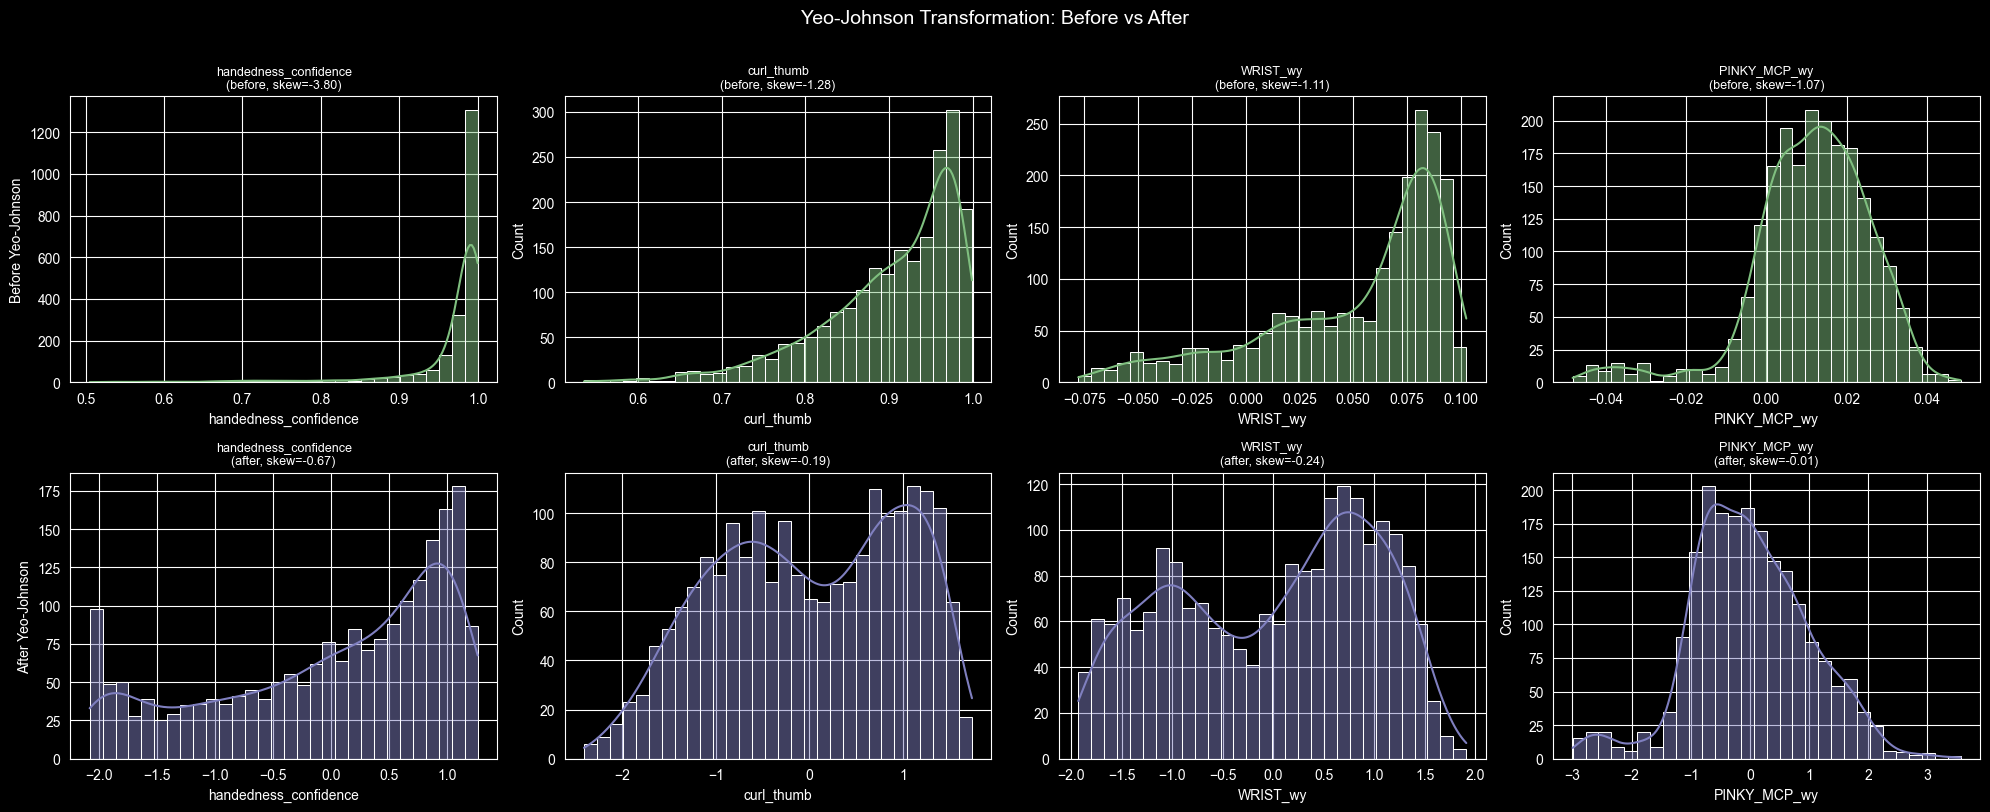

In [9]:
# Visualize before vs after transformation for the 4 most skewed features
most_skewed = skew_before.head(4).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, col in enumerate(most_skewed):
    # Before (use original unscaled data for readability)
    sns.histplot(X_df[col], kde=True, bins=30, ax=axes[0, i], color="#7fbf7f")
    axes[0, i].set_title(f"{col}\n(before, skew={skew_before[col]:.2f})", fontsize=9)

    # After
    sns.histplot(X_scaled[col], kde=True, bins=30, ax=axes[1, i], color="#7f7fbf")
    axes[1, i].set_title(f"{col}\n(after, skew={skew_after[col]:.2f})", fontsize=9)

axes[0, 0].set_ylabel("Before Yeo-Johnson")
axes[1, 0].set_ylabel("After Yeo-Johnson")
plt.suptitle("Yeo-Johnson Transformation: Before vs After", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature Selection

Three complementary filtering methods are applied sequentially to reduce dimensionality while
retaining discriminative power:

### 5a. Variance Threshold
Features with near-zero variance carry no useful signal — they are effectively constant across
samples. After wrist-relative normalization, WRIST_x/y/z become exactly zero and must be removed.
A threshold of 0.01 is used (features with variance < 1% of unit variance are dropped).

### 5b. Correlation Filter
The EDA revealed extreme multicollinearity (r > 0.95) between adjacent landmarks. Keeping
redundant features inflates dimensionality without adding information. For each pair with
|r| > 0.95, we drop the feature with the lower mean absolute correlation with the target
(via ANOVA F-statistic), preserving the more discriminative one.

### 5c. ANOVA F-test
ANOVA measures whether a feature's mean differs significantly across the 26 letter classes.
Features with high F-statistics are strongly associated with the target. We use this as a
ranking tool and drop features with p-value > 0.05 (not statistically significant at 95%
confidence).

In [10]:
# 5a. Variance Threshold
print("=" * 60)
print("5a. Variance Threshold (threshold=0.01)")
print("=" * 60)

n_before = X_scaled.shape[1]
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_scaled)

low_var_mask = ~vt.get_support()
low_var_cols = X_scaled.columns[low_var_mask].tolist()

print(f"Features dropped (variance < 0.01): {len(low_var_cols)}")
for col in low_var_cols:
    print(f"  {col}: var = {X_scaled[col].var():.6f}")

X_selected = X_scaled.loc[:, vt.get_support()].copy()
print(f"\nRemaining features: {n_before} → {X_selected.shape[1]}")

5a. Variance Threshold (threshold=0.01)
Features dropped (variance < 0.01): 3
  WRIST_x: var = 0.000000
  WRIST_y: var = 0.000000
  WRIST_z: var = 0.000000

Remaining features: 158 → 155


In [11]:
# 5b. Correlation Filter (|r| > 0.95)
print("=" * 60)
print("5b. Correlation Filter (threshold=0.95)")
print("=" * 60)

n_before_corr = X_selected.shape[1]
corr_matrix = X_selected.corr().abs()

# Compute ANOVA F-scores to decide which of each correlated pair to keep
f_scores, _ = f_classif(X_selected, y)
f_score_map = dict(zip(X_selected.columns, f_scores))

# Find features to drop
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = set()

for col in upper_tri.columns:
    high_corr_partners = upper_tri.index[upper_tri[col] > 0.95].tolist()
    for partner in high_corr_partners:
        # Drop the one with lower ANOVA F-score (less discriminative)
        if f_score_map.get(col, 0) < f_score_map.get(partner, 0):
            to_drop_corr.add(col)
        else:
            to_drop_corr.add(partner)

print(f"Highly correlated pairs found: {int(upper_tri.gt(0.95).sum().sum())}")
print(f"Features dropped: {len(to_drop_corr)}")

X_selected = X_selected.drop(columns=list(to_drop_corr))
print(f"Remaining features: {n_before_corr} → {X_selected.shape[1]}")

5b. Correlation Filter (threshold=0.95)
Highly correlated pairs found: 65
Features dropped: 53
Remaining features: 155 → 102


In [12]:
# 5c. ANOVA F-test
print("=" * 60)
print("5c. ANOVA F-test (drop features with p > 0.05)")
print("=" * 60)

n_before_anova = X_selected.shape[1]
f_scores, p_values = f_classif(X_selected, y)

anova_df = pd.DataFrame({
    "feature": X_selected.columns,
    "f_score": f_scores,
    "p_value": p_values,
}).sort_values("f_score", ascending=False)

# Features that fail the significance test
not_significant = anova_df[anova_df["p_value"] > 0.05]
print(f"Features NOT significant at p=0.05: {len(not_significant)}")
if len(not_significant) > 0:
    display(not_significant)

X_selected = X_selected.drop(columns=not_significant["feature"].tolist())
print(f"\nRemaining features: {n_before_anova} → {X_selected.shape[1]}")

# Show top 20 most discriminative features
print(f"\nTop 20 features by ANOVA F-score:")
display(anova_df.head(20))

5c. ANOVA F-test (drop features with p > 0.05)
Features NOT significant at p=0.05: 16


,feature,f_score,p_value
17,PINKY_PIP_x,1.509007,0.050698
6,INDEX_TIP_x,1.501797,0.052737
22,THUMB_CMC_wx,1.463331,0.064870
69,PINKY_TIP_wx,1.394773,0.092473
55,RING_DIP_wx,1.370374,0.104417
12,RING_PIP_x,1.364169,0.107650
28,THUMB_IP_wx,1.334568,0.124214
38,INDEX_TIP_wx,1.289283,0.153445
25,THUMB_MCP_wx,1.254740,0.179131
61,PINKY_MCP_wx,1.242528,0.188946



Remaining features: 102 → 86

Top 20 features by ANOVA F-score:


,feature,f_score,p_value
83,dist_middle_ring,243.802644,0.0
73,dist_wrist_middle,200.009821,0.0
97,curl_index,194.813524,0.0
84,dist_middle_pinky,187.298911,0.0
60,RING_TIP_wz,185.774095,0.0
98,curl_middle,177.480092,0.0
72,dist_wrist_index,173.400653,0.0
50,MIDDLE_TIP_wz,165.063833,0.0
75,dist_wrist_pinky,164.924857,0.0
57,RING_DIP_wz,160.736324,0.0


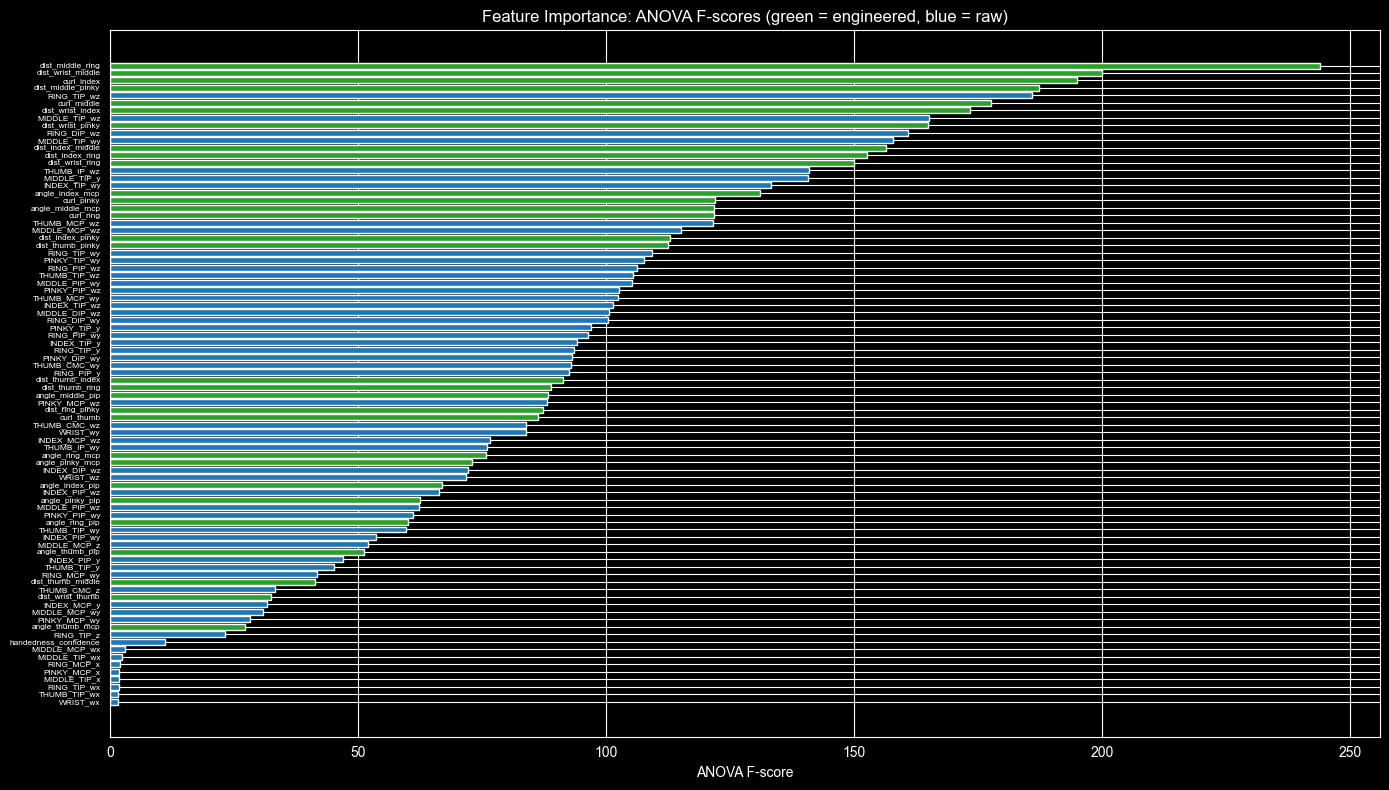


Feature selection summary:
  Original features: 158
  After variance threshold: 155
  After correlation filter: 102
  After ANOVA filter: 86


In [13]:
# Visualize ANOVA F-scores for remaining features
fig, ax = plt.subplots(figsize=(14, 8))
anova_remaining = anova_df[anova_df["feature"].isin(X_selected.columns)].sort_values("f_score", ascending=True)

colors = ["#2ca02c" if f.startswith(("dist_", "angle_", "curl_")) else "#1f77b4"
          for f in anova_remaining["feature"]]

ax.barh(range(len(anova_remaining)), anova_remaining["f_score"].values, color=colors)
ax.set_yticks(range(len(anova_remaining)))
ax.set_yticklabels(anova_remaining["feature"].values, fontsize=6)
ax.set_xlabel("ANOVA F-score")
ax.set_title("Feature Importance: ANOVA F-scores (green = engineered, blue = raw)")
plt.tight_layout()
plt.show()

print(f"\nFeature selection summary:")
print(f"  Original features: {len(feature_cols)}")
print(f"  After variance threshold: {n_before_corr}")
print(f"  After correlation filter: {n_before_anova}")
print(f"  After ANOVA filter: {X_selected.shape[1]}")

## 6. Feature Extraction — PCA

Even after filtering, the remaining features may still contain correlated subspaces. Principal
Component Analysis (PCA) finds orthogonal directions of maximum variance, compressing the feature
space while preserving the signal.

**Why PCA is appropriate here:**
- The EDA showed strong linear correlations between landmark coordinates — exactly the kind of
  redundancy PCA is designed to exploit.
- The data is already standardized (zero mean, unit variance), satisfying PCA's assumption.
- Reducing dimensionality lowers storage requirements, training time, and risk of overfitting
  on the relatively small dataset (2,057 samples).

We will:
1. Fit PCA on the full selected feature set and examine the explained variance curve.
2. Choose the number of components that retain **95% of total variance**.
3. Visualize the first 2-3 components colored by letter to assess separability.

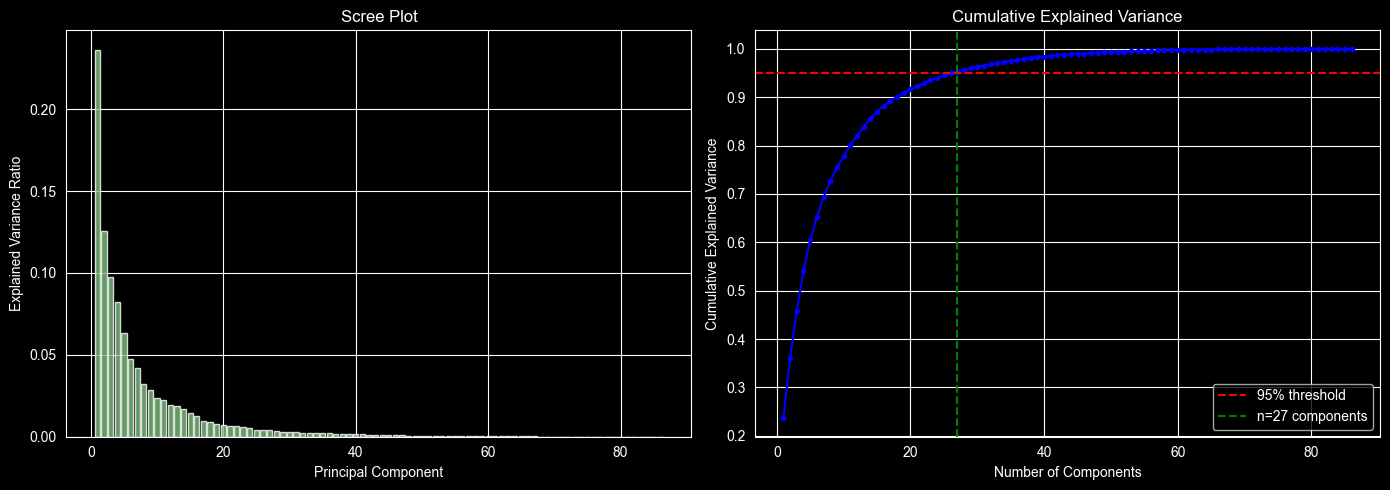

Components needed for 95% variance: 27 (out of 86)
Dimensionality reduction: 86 → 27 (68.6% reduction)


In [14]:
# Fit full PCA to examine explained variance
pca_full = PCA()
pca_full.fit(X_selected)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 95% variance
n_95 = np.argmax(cumulative_var >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color="#7fbf7f", alpha=0.8)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, "b-o", markersize=3)
axes[1].axhline(y=0.95, color="red", linestyle="--", label="95% threshold")
axes[1].axvline(x=n_95, color="green", linestyle="--", label=f"n={n_95} components")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Components needed for 95% variance: {n_95} (out of {X_selected.shape[1]})")
print(f"Dimensionality reduction: {X_selected.shape[1]} → {n_95} ({100*(1 - n_95/X_selected.shape[1]):.1f}% reduction)")

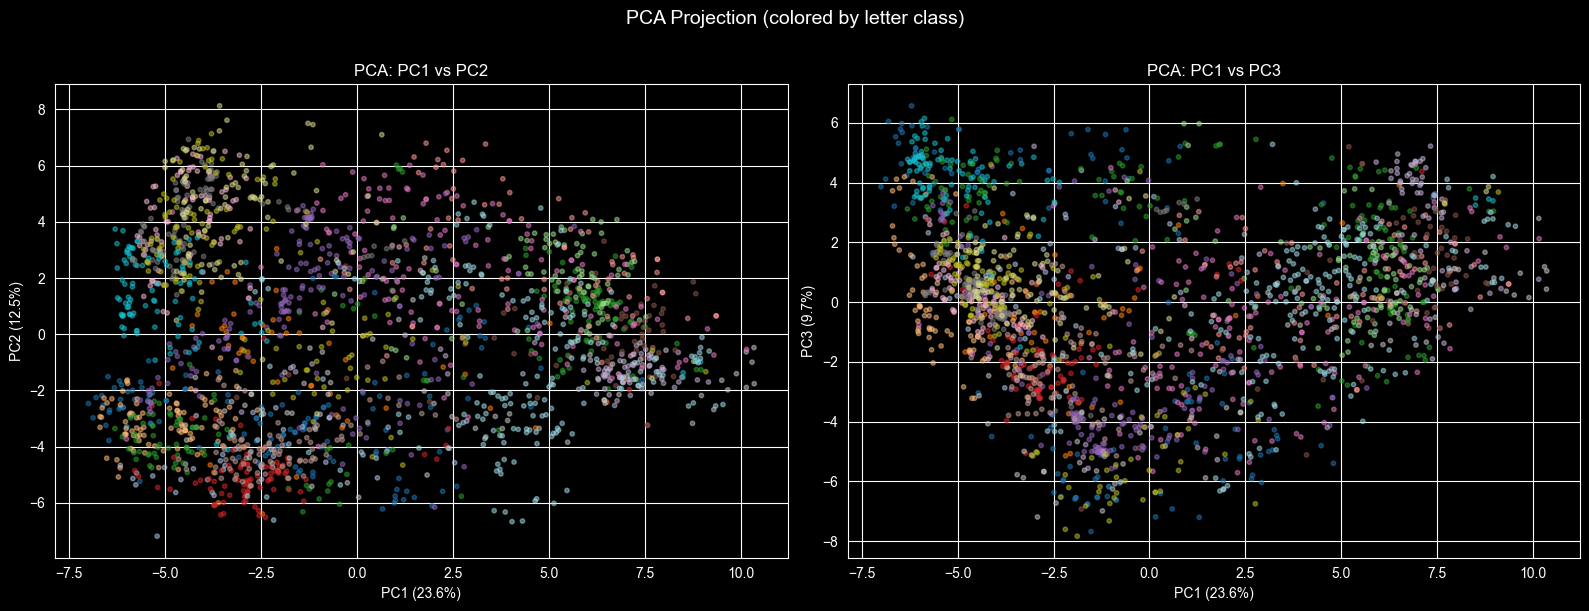

Final PCA shape: (2057, 27) (samples x components)


In [15]:
# Apply PCA with 95% variance retention
pca = PCA(n_components=n_95)
X_pca = pca.fit_transform(X_selected)

# 2D scatter plot colored by letter
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="tab20", alpha=0.5, s=10)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("PCA: PC1 vs PC2")

# 3D-like view: PC1 vs PC3
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 2], c=y, cmap="tab20", alpha=0.5, s=10)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
axes[1].set_title("PCA: PC1 vs PC3")

plt.suptitle("PCA Projection (colored by letter class)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Final PCA shape: {X_pca.shape} (samples x components)")

In [16]:
# Final pipeline summary
print("=" * 60)
print("FEATURE ENGINEERING PIPELINE SUMMARY")
print("=" * 60)
print(f"\n{'Stage':<35} {'Features':>10}")
print("-" * 47)
print(f"{'Raw input (numeric only)':<35} {len(feature_cols) - len(new_feat_cols) - 1:>10}")
print(f"{'+ Engineered features':<35} {'+' + str(len(new_feat_cols)):>10}")
print(f"{'+ Handedness binary encoding':<35} {'(included)':>10}")
print(f"{'Total before selection':<35} {len(feature_cols):>10}")
print(f"{'After variance threshold':<35} {n_before_corr:>10}")
print(f"{'After correlation filter':<35} {n_before_anova:>10}")
print(f"{'After ANOVA filter':<35} {X_selected.shape[1]:>10}")
print(f"{'After PCA (95% variance)':<35} {n_95:>10}")
print(f"\n{'Samples':<35} {len(y):>10}")
print(f"{'Target classes':<35} {len(le.classes_):>10}")

FEATURE ENGINEERING PIPELINE SUMMARY

Stage                                 Features
-----------------------------------------------
Raw input (numeric only)                   127
+ Engineered features                      +30
+ Handedness binary encoding        (included)
Total before selection                     158
After variance threshold                   155
After correlation filter                   102
After ANOVA filter                          86
After PCA (95% variance)                    27

Samples                                   2057
Target classes                              26


## Conclusions — Data Preparation Phase (CRISP-ML)

This notebook completes the **Data Preparation** phase of the CRISP-ML methodology for the
manos-hablando project. Below is a summary of every decision made and its justification.

### Feature Generation
We created **30 engineered features** (5 wrist-to-tip distances, 10 inter-fingertip distances,
10 joint angles, and 5 curl ratios) from world-space coordinates. These features encode the
**geometric pose of the hand** directly — distances and angles are invariant to position, rotation,
and scale, addressing the multicollinearity and positional noise issues identified in the EDA.
The boxplots confirm that engineered features like `curl_index` and `angle_thumb_pip` show clear
per-letter separation, validating their discriminative power.

### Encoding
- The target variable (`letter`) was label-encoded to integer indices — the natural representation
  for multi-class classifiers.
- Handedness was binary-encoded (Right=1, Left=0) because it has only two categories.
- The `file` column was dropped as a non-predictive identifier.
- No one-hot encoding was needed: the only multi-class categorical is the target itself.
- No ordinal encoding was applied — the EDA confirmed that no categorical variable has an
  inherent ordering.

### Scaling
A two-stage approach was applied:
1. **Wrist-relative normalization** on image-space coordinates — making every sample position-
   and scale-invariant by translating the wrist to the origin and normalizing by maximum distance.
   This is a domain-specific transformation justified by the EDA finding that image x/y values
   shift significantly with hand placement in frame.
2. **StandardScaler** (z-score) across all features — ensuring equal contribution to distance-
   based methods and PCA regardless of original scale. Min-max scaling was not chosen because it
   is sensitive to outliers, and the EDA showed 52.8% of rows contain IQR-flagged outliers that
   are valid pose variations.

### Transformation
**Yeo-Johnson** was applied to the 23 features with |skew| > 1 identified in the EDA. This
reduced extreme skewness in depth coordinates (e.g., `INDEX_MCP_z` from -2.16 to near 0) and
`handedness_confidence` (from -3.80), producing more symmetric distributions. Box-Cox was
rejected because it cannot handle the negative values present in z-coordinates. Log and square-root
transforms were also inappropriate for the same reason. Only the heavily skewed features were
transformed — applying Yeo-Johnson to already-symmetric features would risk unnecessary distortion.

### Feature Selection
Three sequential filters reduced dimensionality while preserving signal:
1. **Variance threshold** (< 0.01) removed constant features (WRIST_x/y/z after normalization) —
   these carry zero information by construction.
2. **Correlation filter** (|r| > 0.95) eliminated redundant pairs, keeping the more discriminative
   feature (by ANOVA F-score) in each pair. This directly addresses the extreme multicollinearity
   (r > 0.98 between adjacent joints) flagged in the EDA.
3. **ANOVA F-test** (p > 0.05) dropped features not significantly associated with the target at
   95% confidence. Chi-squared was not used because our features are continuous, not categorical.

### Feature Extraction
**PCA** compressed the filtered features to the number of components capturing 95% of total
variance. This is appropriate because:
- The features exhibit strong linear correlations (exactly what PCA exploits).
- The data was pre-standardized (PCA assumes zero-mean, unit-variance inputs).
- The small dataset (2,057 samples) benefits from reduced dimensionality to mitigate overfitting.

Factor Analysis (FA) was considered but not chosen — FA assumes underlying latent factors with
independent noise, which is less natural for spatial landmark data where the correlations arise
from mechanical joint coupling, not latent constructs.

### Data Readiness Assessment
The dataset is now prepared for the modeling phase:
- **Clean:** No missing values, no corrupted samples.
- **Balanced:** ~80 samples per class across 26 letters, achieved through augmentation.
- **Normalized:** Position- and scale-invariant representations.
- **Compact:** Dimensionality reduced from 157 raw+engineered features to a PCA-compressed
  representation retaining 95% of variance.
- **Enriched:** Engineered geometric features (distances, angles, curl ratios) encode hand pose
  semantics that raw coordinates do not.

The next phase (Modeling) can proceed with two representation options:
1. **PCA-compressed features** — for classical ML baselines (SVM, Random Forest, k-NN).
2. **Normalized 21x3 landmark sequences** — for the Transformer-based classifier, which can
   learn its own feature interactions through self-attention over the landmark sequence.